In [58]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.metrics import*
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import tensorflow as tf
import keras 
from keras import layers
from keras.layers import Dense,Flatten
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.callbacks import EarlyStopping,Callback

In [2]:
df  = pd.read_csv("Churn.csv")

In [3]:
df.shape

(10000, 14)

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [6]:
cols = list(df.columns)

In [7]:
cols

['RowNumber',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [11]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
cat_cols = ['Tenure','NumOfProducts','HasCrCard','IsActiveMember','Exited','Geography','Gender']

In [13]:
remove_col = ['RowNumber','CustomerId','Surname',]

for i in remove_col:
    cols.remove(i)


In [14]:
cols

['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [15]:
num_cols = list(set(cols)-set(cat_cols))

In [16]:
num_cols

['Age', 'CreditScore', 'EstimatedSalary', 'Balance']

Tenure
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64
Tenure
2     10.48
1     10.35
7     10.28
8     10.25
5     10.12
3     10.09
4      9.89
9      9.84
6      9.67
10     4.90
0      4.13
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


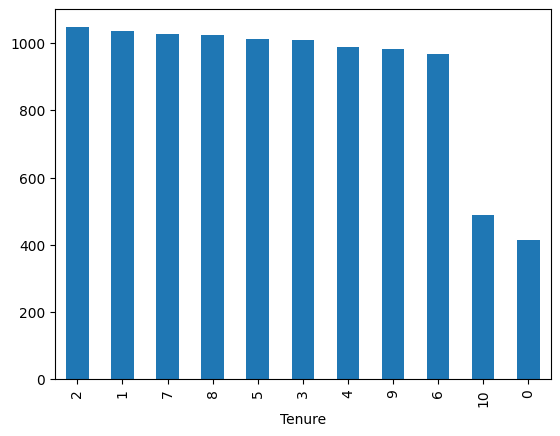

**************************************************
NumOfProducts
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
NumOfProducts
1    50.84
2    45.90
3     2.66
4     0.60
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


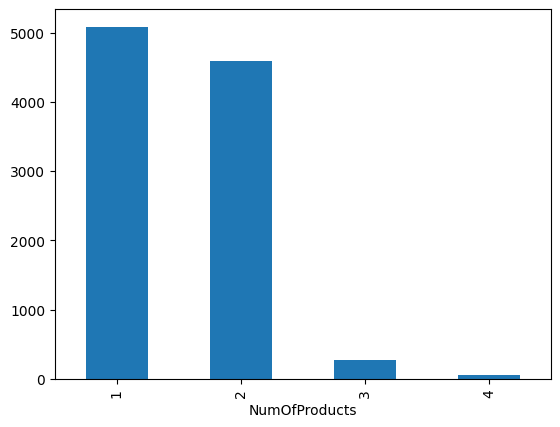

**************************************************
HasCrCard
HasCrCard
1    7055
0    2945
Name: count, dtype: int64
HasCrCard
1    70.55
0    29.45
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


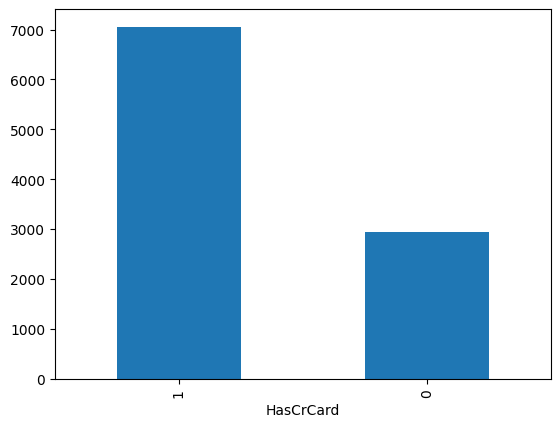

**************************************************
IsActiveMember
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64
IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


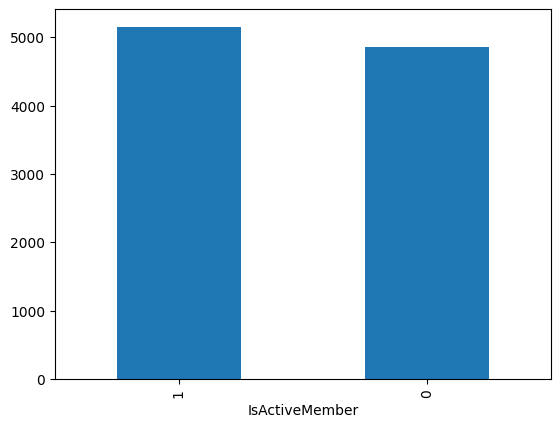

**************************************************
Exited
Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


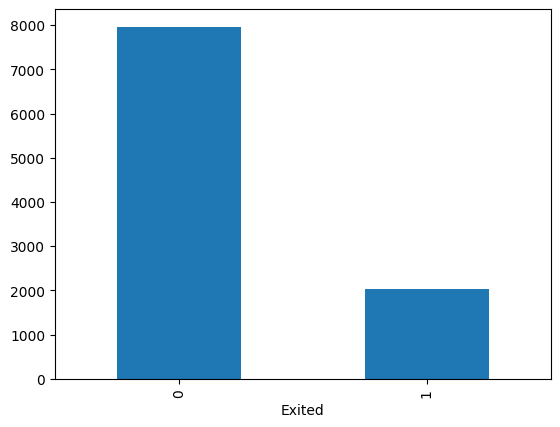

**************************************************
Geography
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


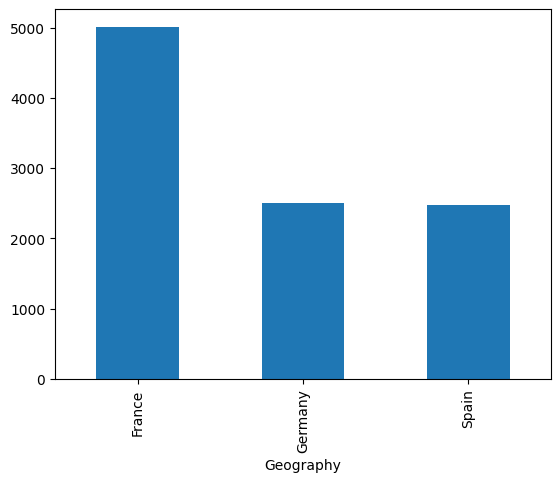

**************************************************
Gender
Gender
Male      5457
Female    4543
Name: count, dtype: int64
Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64
Axes(0.125,0.11;0.775x0.77)


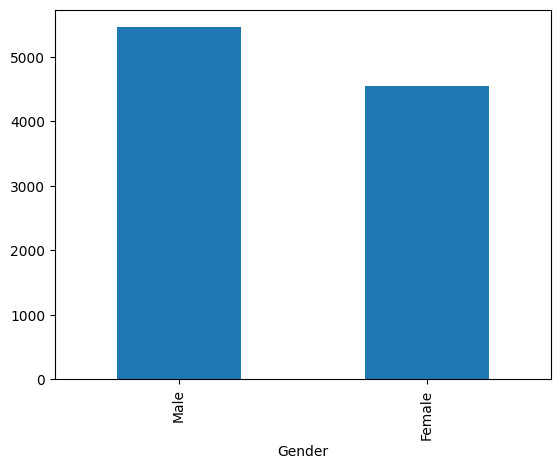

**************************************************


In [17]:
for i in cat_cols:
    print(i)
    print(df[i].value_counts())
    print(df[i].value_counts(normalize=True)*100)
    print(df[i].value_counts().plot.bar())
    plt.show()
    print("*"*50)


Age
Axes(0.125,0.11;0.775x0.77)


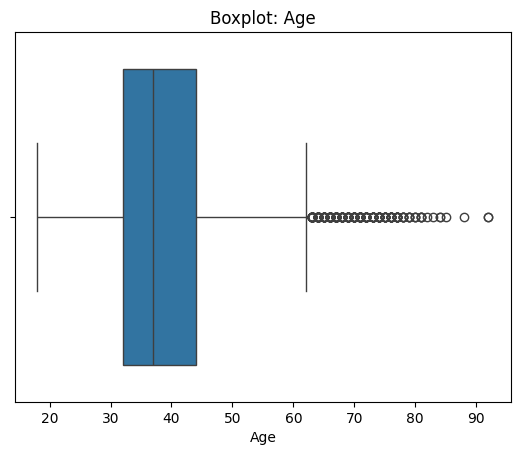

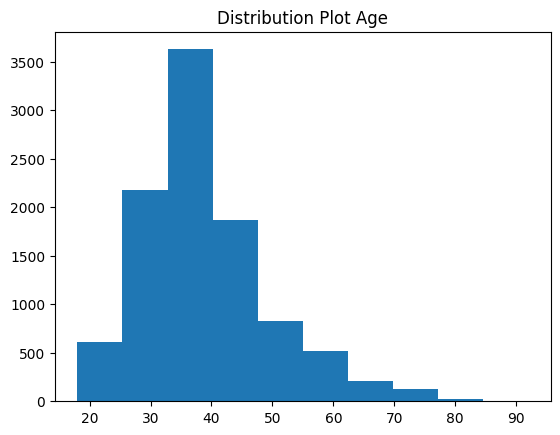

**************************************************
CreditScore
Axes(0.125,0.11;0.775x0.77)


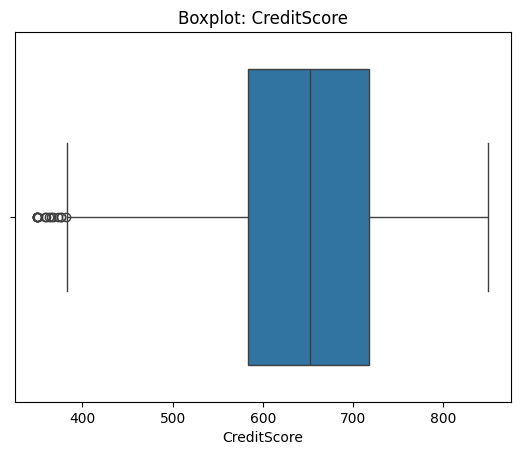

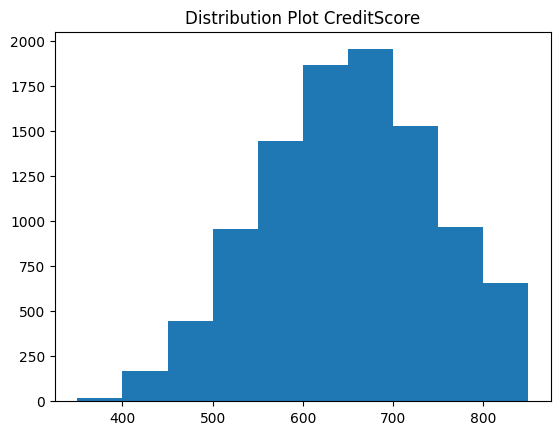

**************************************************
EstimatedSalary
Axes(0.125,0.11;0.775x0.77)


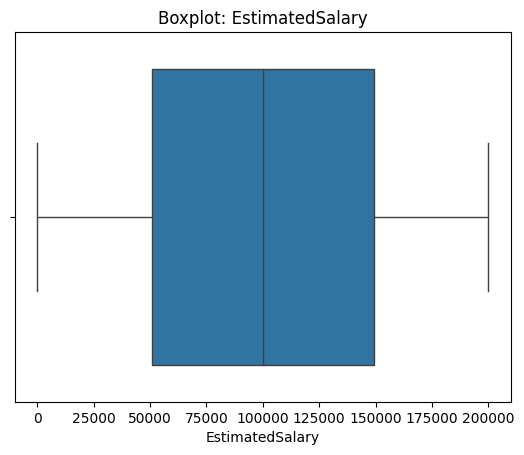

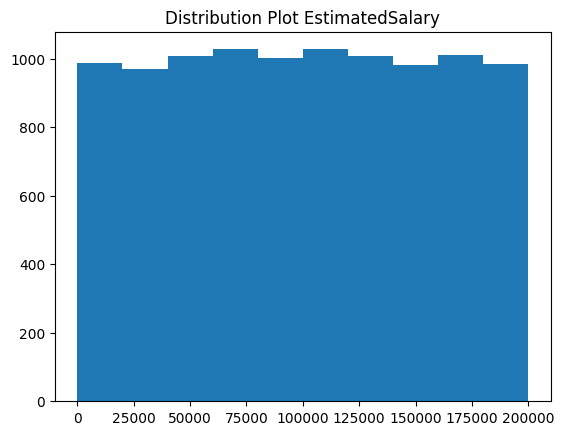

**************************************************
Balance
Axes(0.125,0.11;0.775x0.77)


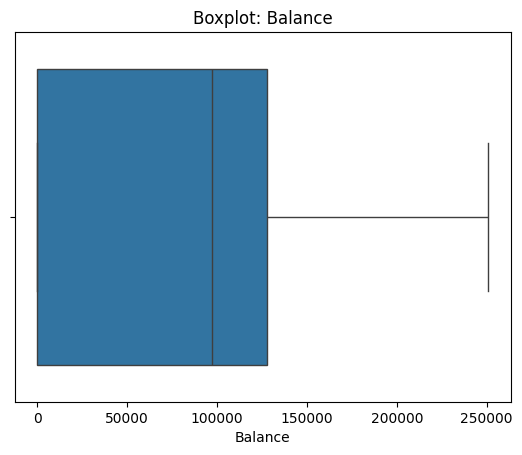

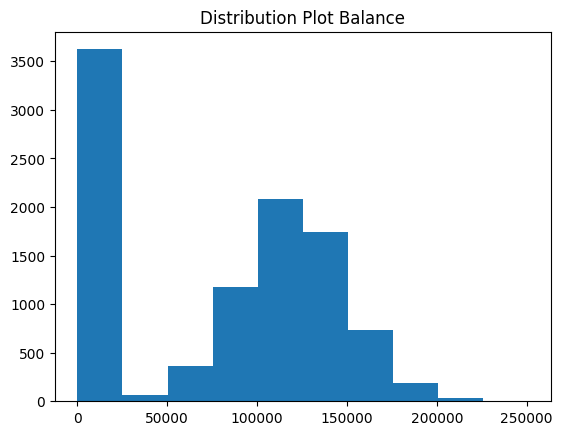

**************************************************


In [18]:
for i in num_cols:
    print(i)
    plt.title(f"Boxplot: {i}")
    print(sns.boxplot(df[i],orient='h'))
    plt.show()
    plt.hist(df[i])
    plt.title(f"Distribution Plot {i}")
    plt.show()
    print("*"*50)

Age


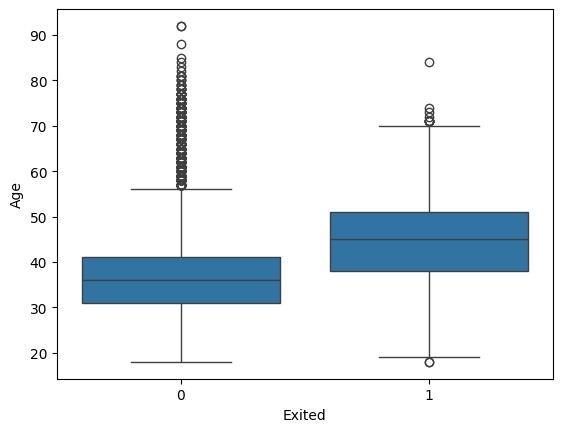

****************************************************************************************************
CreditScore


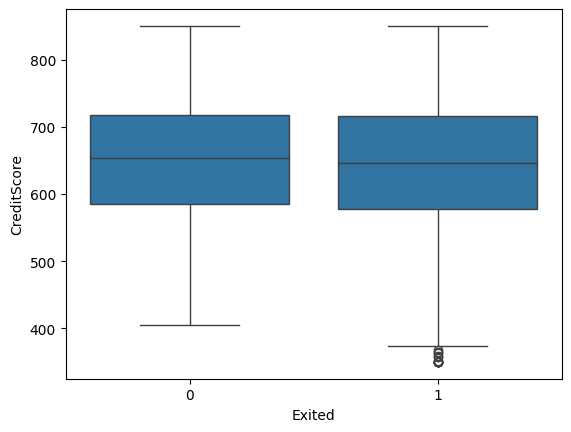

****************************************************************************************************
EstimatedSalary


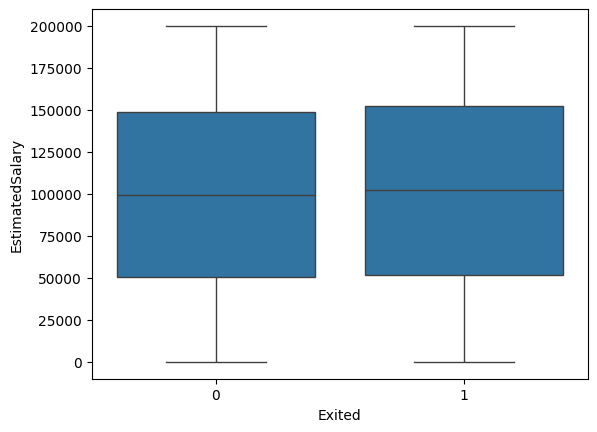

****************************************************************************************************
Balance


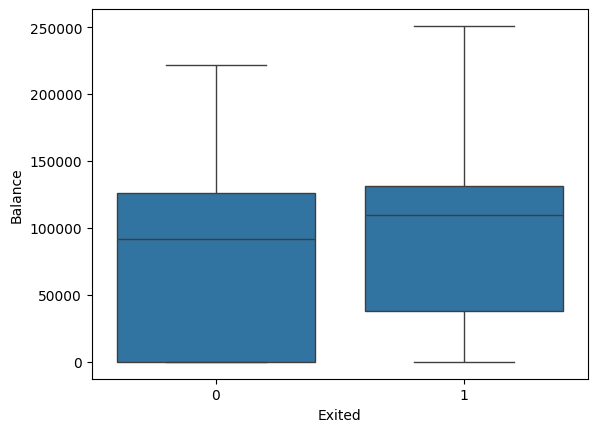

****************************************************************************************************


In [19]:
#Bilateral Analysis
for i in num_cols:
    print(i)
    sns.boxplot(x='Exited',y=i , data=df)
    plt.show()
    print('**'*50)

<Axes: >

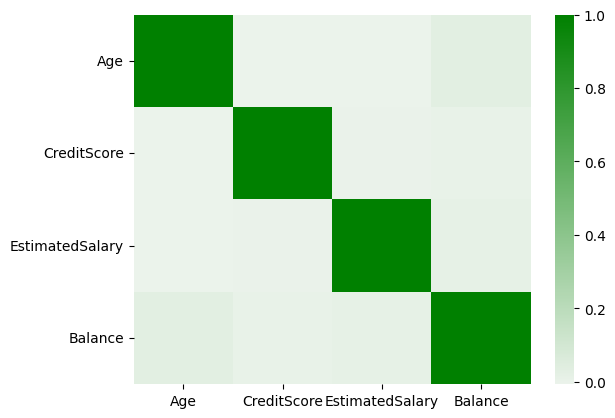

In [20]:
cmap = sns.light_palette('green',as_cmap=True)
sns.heatmap(df[num_cols].corr(),cmap=cmap)

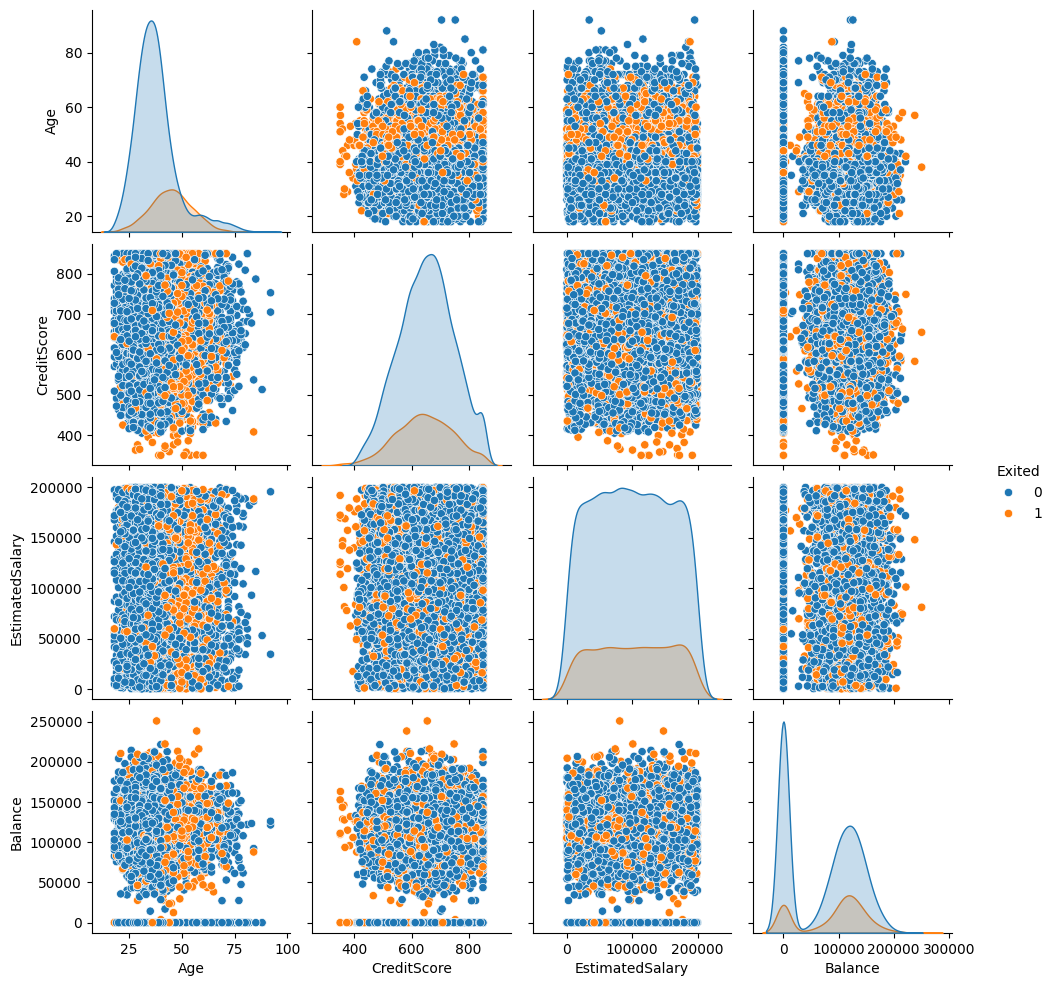

In [ ]:
sns.pairplot(df[num_cols+['Exited']],hue='Exited')

Tenure


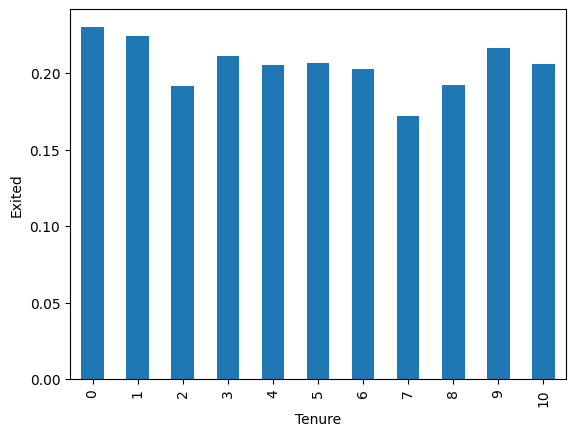

NumOfProducts


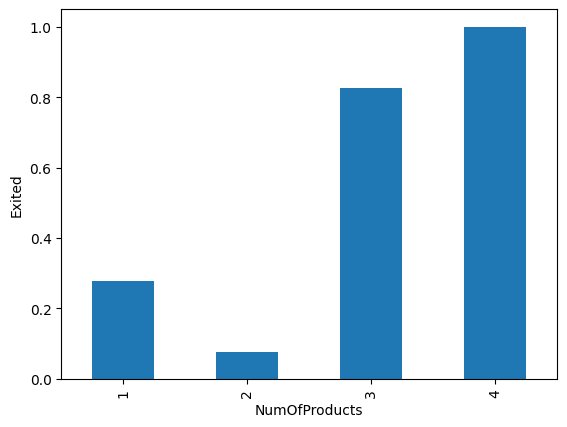

HasCrCard


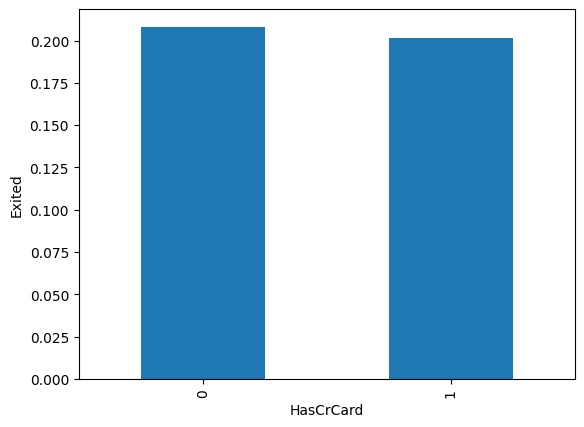

IsActiveMember


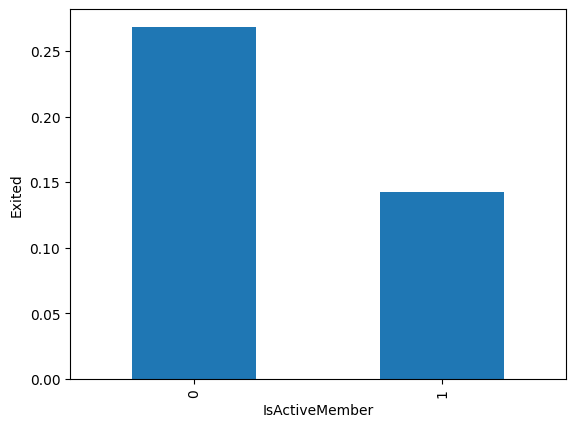

Exited


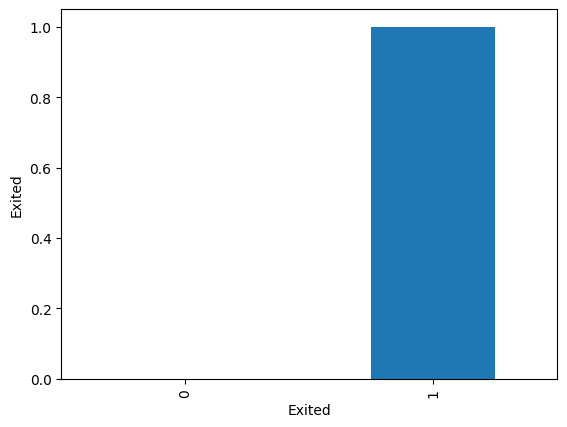

Geography


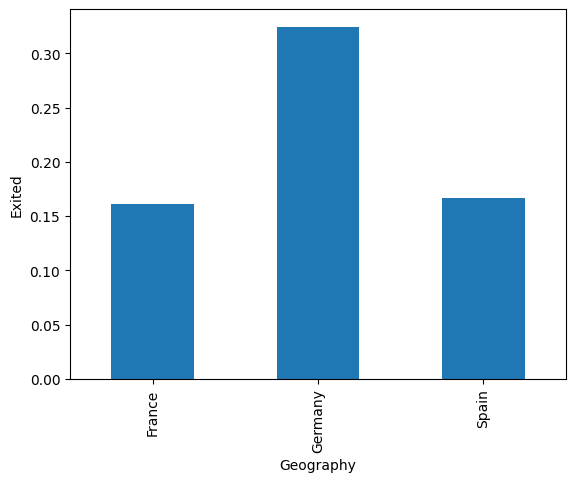

Gender


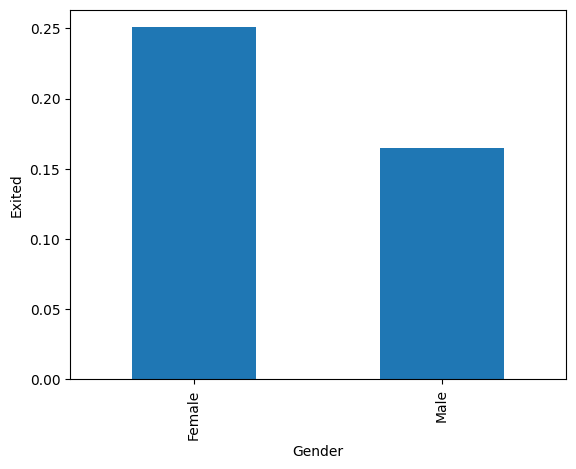

In [23]:
#Bivarte Analysis of categorical data points 
for i in cat_cols:
    print(i)
    df.groupby(i)['Exited'].mean().plot.bar()
    plt.ylabel("Exited")
    plt.show()

In [27]:
df['Gender'].value_counts()
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [29]:
df['Geography'] = df['Geography'].map({'France':0,'Germany':1,'Spain':2}).astype("int")
df['Gender'] = df['Gender'].map({'Female':0,'Male':1}).astype('int')


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  int64  
 5   Gender           10000 non-null  int64  
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(11), str(1)
memory usage: 1.1 MB


In [43]:
x =df[num_cols+cat_cols].drop(columns=['Exited'])

In [44]:
x

,Age,CreditScore,EstimatedSalary,Balance,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Geography,Gender
0,42,619,101348.88,0.00,2,1,1,1,0,0
1,41,608,112542.58,83807.86,1,1,0,1,2,0
2,42,502,113931.57,159660.80,8,3,1,0,0,0
3,39,699,93826.63,0.00,1,2,0,0,0,0
4,43,850,79084.10,125510.82,2,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...
9995,39,771,96270.64,0.00,5,2,1,0,0,1
9996,35,516,101699.77,57369.61,10,1,1,1,0,1
9997,36,709,42085.58,0.00,7,1,0,1,0,0
9998,42,772,92888.52,75075.31,3,2,1,0,1,1


In [45]:
y = df['Exited']

In [46]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [47]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [48]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(8000, 10) (2000, 10) (8000,) (2000,)


In [49]:
x_test

,Age,CreditScore,EstimatedSalary,Balance,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Geography,Gender
6252,32,596,41788.37,96709.07,3,2,0,0,1,1
4684,43,623,146379.30,0.00,1,2,1,1,0,1
1731,44,601,58561.31,0.00,4,2,1,0,2,0
4742,59,506,170679.74,119152.10,8,2,1,1,1,1
4521,27,560,114669.79,124995.98,7,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...
6412,53,602,45038.29,98268.84,5,1,0,1,1,0
8285,25,609,109895.16,0.00,10,1,0,1,0,1
7853,47,730,33373.26,0.00,7,1,1,0,0,0
1095,29,692,76755.99,0.00,4,1,1,0,0,1


In [50]:
lg = LogisticRegression()
lg.fit(x_train,y_train)
y_pred = lg.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89      1607
           1       0.44      0.08      0.13       393

    accuracy                           0.80      2000
   macro avg       0.62      0.53      0.51      2000
weighted avg       0.74      0.80      0.74      2000



/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1607
           1       0.45      0.52      0.48       393

    accuracy                           0.78      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.79      0.78      0.79      2000



#Deep Learning Models 

In [56]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [60]:
classifier = Sequential()
classifier.add(Dense(64,activation='relu',input_dim=x_train.shape[1]))
classifier.add(Dense(32,activation='relu'))
classifier.add(Dense(1,activation='sigmoid'))
classifier.summary()

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.6293266205160478), 1: np.float64(2.4330900243309004)}


In [61]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [81]:
history = classifier.fit(x_train, y_train, epochs=50, batch_size=32)


Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 392us/step - accuracy: 0.9143 - loss: 0.2038
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 367us/step - accuracy: 0.9149 - loss: 0.2003
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - accuracy: 0.9146 - loss: 0.1998
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - accuracy: 0.9144 - loss: 0.2013
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - accuracy: 0.9130 - loss: 0.2010
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 365us/step - accuracy: 0.9172 - loss: 0.2007
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 370us/step - accuracy: 0.9140 - loss: 0.2023
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - accuracy: 0.9126 - loss: 0.2013
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 368us/step - accuracy: 0.9129 - loss: 0.2020
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 369us/step - accuracy: 0.9151 - loss: 0.2019
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 371us/step - accuracy: 0.9146 - loss: 0.2024
Epoch 12/50
250/250 ━━━━━━━━━━

In [82]:
y_prob = classifier.predict(x_test)
print(f"maxvalue{y_prob.max()} and min vlaue is {y_prob.min()}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 315us/step
maxvalue0.0 and min vlaue is 0.0


In [83]:
fpr ,tpr,threshold = roc_curve(y_test,y_prob)
j_score = tpr-fpr
best_idx = j_score.argmax()
best_threshold = threshold[best_idx]
print(best_threshold)
y_pred = (y_prob>=best_threshold).astype(int)

inf


In [84]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [85]:
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


KeyError: 'val_accuracy'

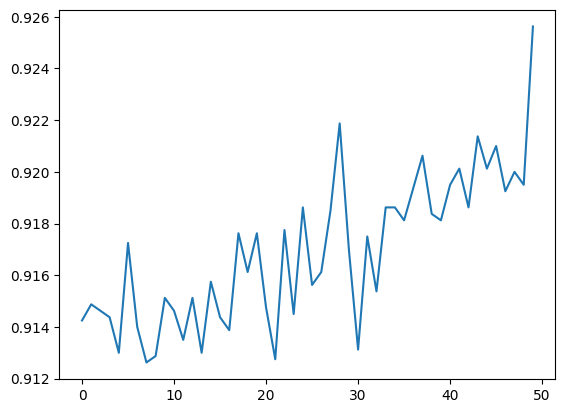

In [86]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("model_accuracy")
plt.ylabel('accuary')
plt.xlabel('epoch')
plt.legend(['train','test'],loc="upper left")
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("model_loss")
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc="upper left")
plt.show()